In [1]:
import numpy as np
import pandas as pd

from cluster_visuals import *
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
plt.rcParams["figure.figsize"] = (20,12)
plt.rcParams["xtick.labelsize"] = 16
plt.rcParams["ytick.labelsize"] = 16
plt.rcParams["axes.labelsize"] = 20

from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score


In [2]:
# Load features from feats.csv
feats = np.array(np.loadtxt("./features.csv", delimiter=',', dtype=str))[:,0]

# Open the Excel file
excel_file = pd.ExcelFile("stats.xlsx")

adv = pd.read_excel(excel_file, sheet_name="advanced")
adv.index = [adv.PLAYER, adv.SEASON]
adv.drop(columns=["PLAYER", "SEASON"], inplace=True)

cols = []
# Iterate through each sheet and check for columns in feats
for sheet_name in excel_file.sheet_names:
    df = pd.read_excel(excel_file, sheet_name=sheet_name)

    matching_cols = [col for col in df.columns if col in feats]
    if matching_cols:
        if sheet_name == "bio":
            df.index = df.PLAYER
            df.drop(columns=["PLAYER"], inplace=True)
        else:
            df.index = [df.PLAYER, df.SEASON]
            df.drop(columns=["PLAYER", "SEASON"], inplace=True)
        
        for c in matching_cols:
            cols.append(df.loc[:, c])

data = pd.concat(cols, axis=1)
data = data[data.MIN > 720]
data.drop(columns=["MIN"], inplace=True)

#nan is used for players with less than 10 MPG (excluded already) and less than 10 possessions
#these are approximated to 0
data = data.fillna(0)

In [3]:
means = data.mean()
stds = data.std()
Z = (data - means) / (stds)
Z.head()

,,PER36_FGA_TRAD,PER36_3PA_TRAD,PER36_FTA_TRAD,EST.__USG%_ESTADV,EST.__PACE_ESTADV,PER36_POSS_P_ISO,PER36_FGA_P_ISO,PER36_POSS_P_TRANS,PER36_FGA_P_TRANS,PER36_POSS_P_BH,...,PER36_PASS_PAINT,PER36_PF_PAINT,PER36_SCREEN_ASSISTS,PER36_OFF_LOOSE_BALLS_RECOVERED,PER36_OFF_BOX_OUTS,PER36_FGA_RA,PER36_FGA_PAINT_NONRA,PER36_FGA_MID,PER36_FGA_CORNER3,PER36_FGA_ATB3
PLAYER,SEASON,,,,,,,,,,,,,,,,,,,,,
Shai Gilgeous-Alexander,2025,2.728334,0.291755,3.266231,2.671828,1.000078,4.649285,4.780405,-1.025634,-1.029557,2.717694,...,-0.605097,-0.644751,-0.644503,0.232202,-0.588922,1.055984,2.608412,2.540682,-1.360986,0.840438
Anthony Edwards,2025,1.978129,1.832241,1.620156,2.119781,-0.757381,2.999609,2.870179,0.974037,1.035259,2.226432,...,-0.849047,-0.493737,-0.716106,-0.202907,-0.519802,0.379182,0.253581,0.898624,-0.125054,2.123511
Nikola Jokić,2025,1.673495,-0.226732,1.672101,1.728006,0.965618,0.251447,0.250966,0.226994,0.055088,-0.146879,...,1.824243,1.187811,1.860192,4.005772,1.147956,1.153571,2.993954,0.142195,-1.358426,0.113510
Giannis Antetokounmpo,2025,2.124883,-1.582615,4.263651,2.796484,0.045044,-0.629119,-0.628508,-1.025634,-1.029557,0.393176,...,0.097775,1.533385,0.621948,1.845853,0.148140,4.152371,0.715109,2.262265,-1.550861,-1.258247
Jayson Tatum,2025,1.947483,1.765134,1.521915,2.030741,-0.777072,4.076949,4.320160,0.454169,0.417193,1.762618,...,-0.610140,-0.466693,-0.568797,0.259818,-0.475469,0.452694,0.011976,1.105305,-0.877077,2.373641


## PCA

In [4]:
C = Z.cov()
C.head()

,PER36_FGA_TRAD,PER36_3PA_TRAD,PER36_FTA_TRAD,EST.__USG%_ESTADV,EST.__PACE_ESTADV,PER36_POSS_P_ISO,PER36_FGA_P_ISO,PER36_POSS_P_TRANS,PER36_FGA_P_TRANS,PER36_POSS_P_BH,...,PER36_PASS_PAINT,PER36_PF_PAINT,PER36_SCREEN_ASSISTS,PER36_OFF_LOOSE_BALLS_RECOVERED,PER36_OFF_BOX_OUTS,PER36_FGA_RA,PER36_FGA_PAINT_NONRA,PER36_FGA_MID,PER36_FGA_CORNER3,PER36_FGA_ATB3
PER36_FGA_TRAD,1.000000,0.477523,0.629921,0.972006,0.176288,0.586547,0.591783,0.306389,0.298432,0.557571,...,-0.397699,-0.162484,-0.283084,-0.088872,-0.252452,0.239691,0.679754,0.695630,-0.144035,0.602025
PER36_3PA_TRAD,0.477523,1.000000,-0.099230,0.354076,0.088896,0.201508,0.212412,0.247518,0.271498,0.341666,...,-0.704261,-0.620950,-0.649874,-0.239960,-0.579053,-0.563756,-0.114659,0.226808,0.548166,0.952685
PER36_FTA_TRAD,0.629921,-0.099230,1.000000,0.757315,0.097107,0.524445,0.511579,0.140054,0.105036,0.340856,...,0.033405,0.343365,0.144021,0.040548,0.143610,0.596615,0.593703,0.424395,-0.481721,0.060270
EST.__USG%_ESTADV,0.972006,0.354076,0.757315,1.000000,0.112413,0.629167,0.629839,0.284726,0.264599,0.567408,...,-0.318024,-0.066907,-0.194763,-0.068020,-0.177750,0.335124,0.716301,0.690896,-0.273059,0.506576
EST.__PACE_ESTADV,0.176288,0.088896,0.097107,0.112413,1.000000,0.012605,0.009986,0.087363,0.082016,0.061483,...,-0.081454,-0.030339,-0.064515,0.012350,-0.097294,0.122672,0.128423,-0.012052,0.004812,0.100472


34


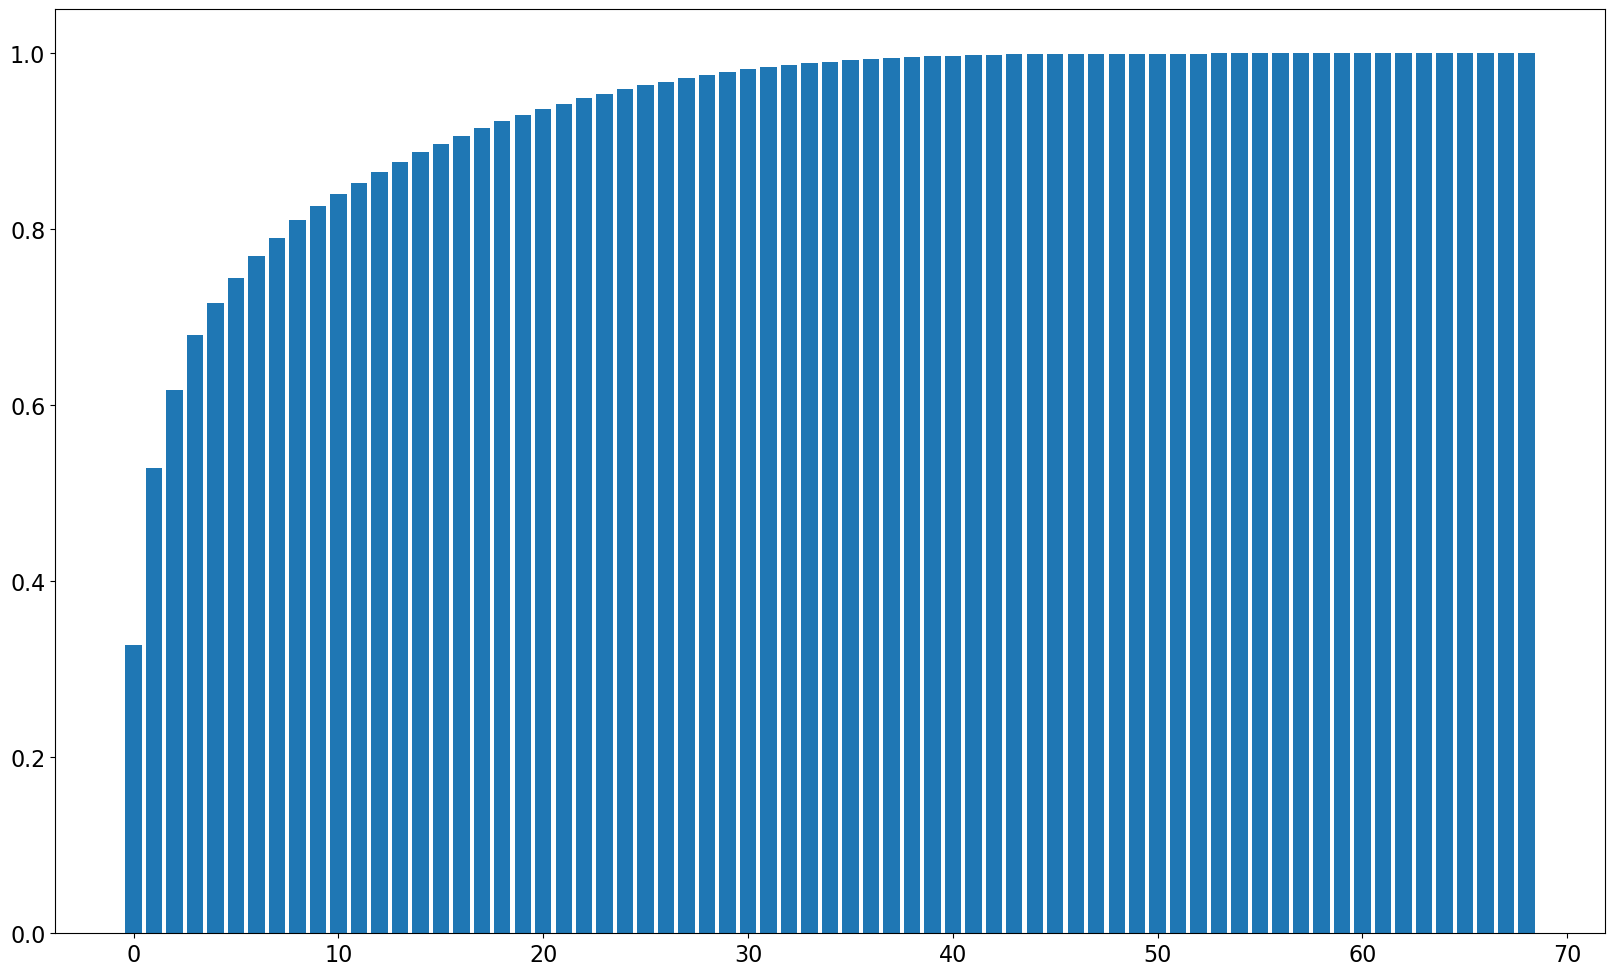

In [5]:
lambdas, vs = np.linalg.eig(C)
l = lambdas/sum(lambdas)
plt.bar(np.arange(0, len(l)), np.cumsum(l))
print(np.where(np.cumsum(l) > 0.99)[0][0])

In [6]:
z = Z.dot(vs).iloc[:, :np.where(np.cumsum(l) > 0.99)[0][0]]
z.head()

,,0,1,2,3,4,5,6,7,8,9,...,24,25,26,27,28,29,30,31,32,33
PLAYER,SEASON,,,,,,,,,,,,,,,,,,,,,
Shai Gilgeous-Alexander,2025,-8.242322,8.868912,-4.050224,-0.051665,-4.837137,-0.135127,0.450024,-1.603278,1.676739,-0.707037,...,0.081206,-0.613406,-0.348262,0.229984,-0.533499,0.167883,-0.169552,0.180065,-0.240016,-0.110587
Anthony Edwards,2025,-7.709881,5.369451,1.388132,-0.249265,-1.991635,-1.287430,1.098000,1.466301,2.298430,0.071268,...,1.012016,0.132025,-0.013095,0.215756,0.400678,0.350683,0.262347,0.256035,0.914395,-0.238230
Nikola Jokić,2025,8.645507,13.995940,1.256197,-4.060086,6.784583,0.318039,-1.426842,1.849861,-1.710097,-0.662321,...,-0.159645,-0.920463,0.727352,0.365327,-0.240342,0.308265,-1.779630,-0.438559,0.078082,0.287667
Giannis Antetokounmpo,2025,2.566724,10.613077,-4.504430,-1.825575,-1.742677,1.208166,-1.584262,1.383100,-1.370703,-1.810087,...,0.869942,-1.845910,1.324419,0.749648,0.369395,1.678803,0.674697,-0.769498,-0.837795,1.112736
Jayson Tatum,2025,-4.944093,6.342953,0.406366,-1.292396,-0.081143,-0.637256,1.771859,1.434147,3.987348,0.761792,...,0.010087,1.093206,0.010902,0.954282,0.316729,-0.048852,0.699415,0.181323,0.835794,-0.191994


## GMM

50%


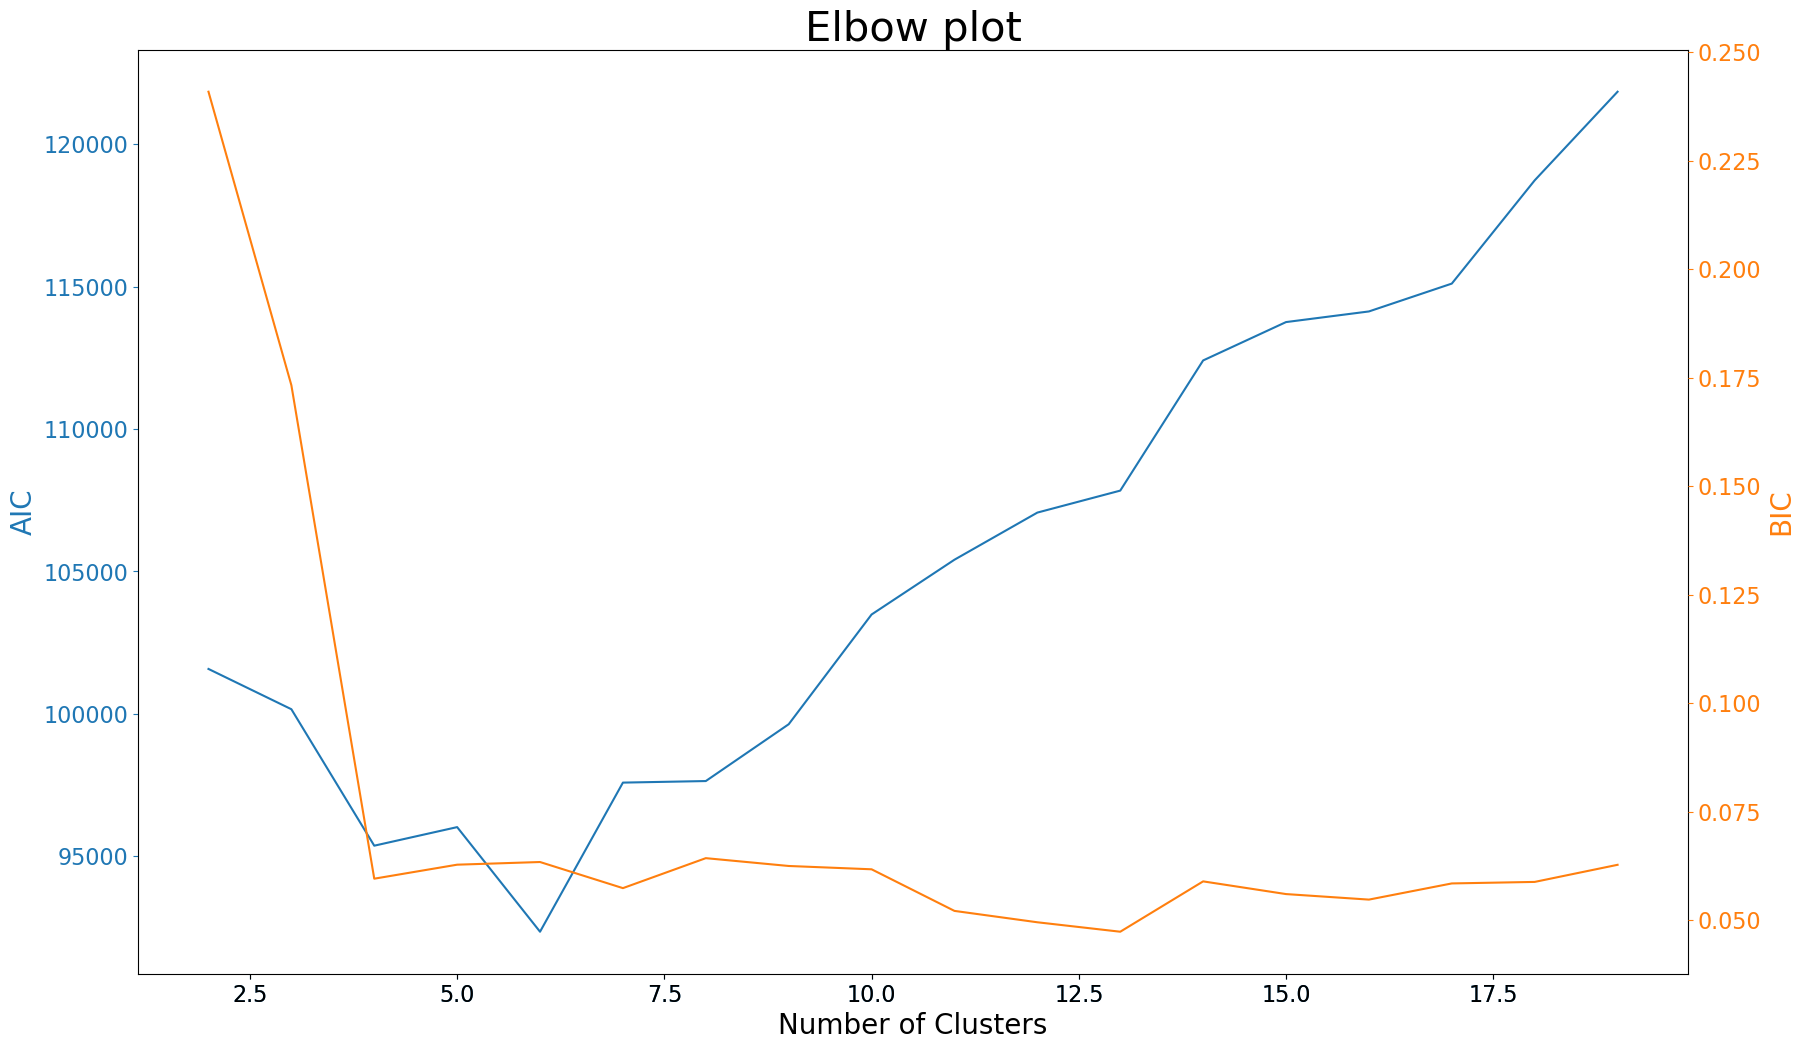

In [7]:
aic = []
bic = []
num_max = 20
for k in range(2, num_max):
    a = []
    b = []
    for i in range(10):
        gm = GaussianMixture(n_components=k, 
                            random_state=i,
                            ).fit(z)
        a.append(silhouette_score(z, gm.predict(z)))
        b.append(gm.bic(z))
    bic.append(min(a))
    aic.append(min(b))
    if k%10 == 0:
        print(f"{100*k/num_max:.0f}%")

bic = np.array(bic)
aic = np.array(aic)
fig=plt.figure()
ax=fig.add_subplot(111, label="1")
ax2=fig.add_subplot(111, label="2", frame_on=False)

ax.plot(np.arange(2, num_max), aic, color="C0")
ax.set_xlabel("Number of Clusters", color="black")
ax.set_ylabel("AIC", color="C0")
ax.tick_params(axis='x', colors="C0")
ax.tick_params(axis='y', colors="C0")

ax2.plot(np.arange(2, num_max), bic, color="C1")
ax2.yaxis.tick_right()
ax2.set_ylabel('BIC', color="C1")       
ax2.yaxis.set_label_position('right') 
ax2.tick_params(axis='y', colors="C1")

plt.title("Elbow plot", fontsize=30)
plt.show()

In [8]:
n = 6
gm = GaussianMixture(n_components=n, 
                     random_state=0,
                     ).fit(z)

centers = gm.means_
data['CLUSTER'+str(n)] = gm.predict(z)

/home/rl/anaconda3/envs/bball/lib/python3.13/site-packages/matplotlib/collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


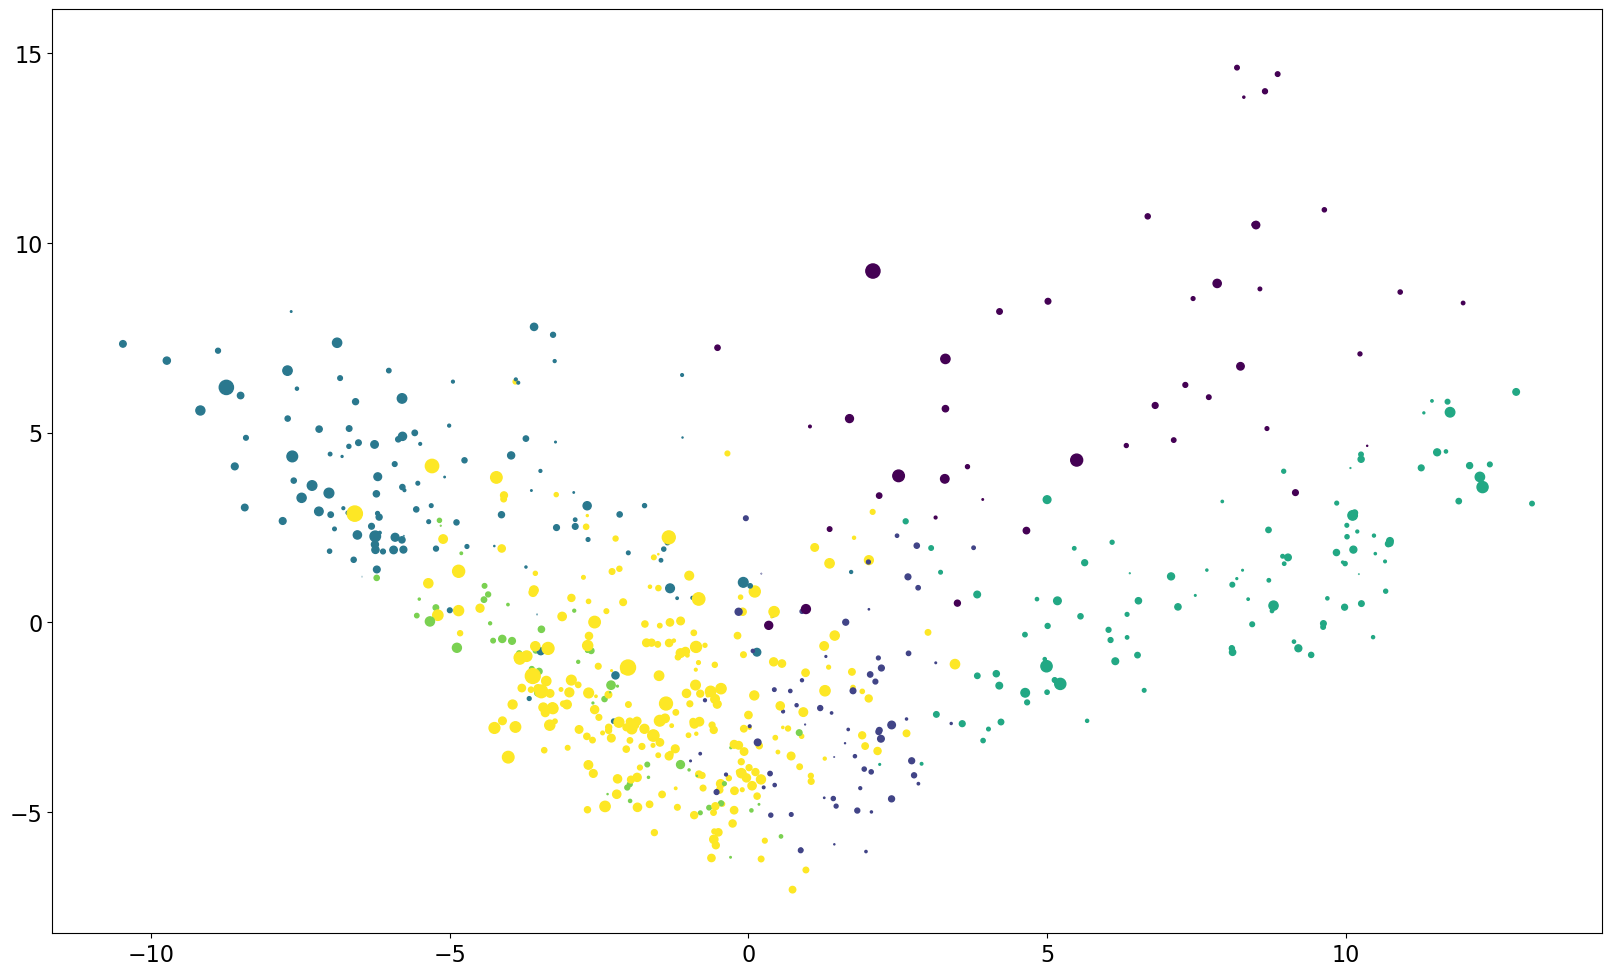

In [11]:
pca1 = 0
pca2 = 1
pca3 = 2
plt.scatter(
        z[pca1],
        z[pca2],
        s = z[pca3]*10,
        c = data['CLUSTER'+str(n)]
)

In [12]:
examples(Z=z, j=0, centers=gm.means_, num=3, n_clusters=n)

NameError: name 'data' is not defined